In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Embedding
from tensorflow.keras.models import Model

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# Download dataset
import kagglehub

dataset_path = kagglehub.dataset_download("adityajn105/flickr8k")
print("Dataset path:", dataset_path)
image_folder = os.path.join(dataset_path, "Images")

d:\FSB\AIN501-HocSau\Final\image-captioning\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\HawkHoang\.cache\kagglehub\datasets\adityajn105\flickr8k\versions\1


In [3]:
feature_dir = "features"
os.makedirs(feature_dir, exist_ok=True)

In [4]:
# Load captions
caption_file = os.path.join(dataset_path, "captions.txt")

captions_dict = {}

with open(caption_file, "r", encoding="utf-8") as f:
    next(f)  # skip header
    for line in f:
        img_name, caption = line.strip().split(",", 1)

        caption = "startseq " + caption.lower() + " endseq"

        if img_name not in captions_dict:
            captions_dict[img_name] = []

        captions_dict[img_name].append(caption)

In [5]:
# Image preprocessing
cnn_encoder = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)
cnn_encoder.trainable = False   # Only use as feature extractor

In [6]:
def extract_image_features(image_path):
    img = tf.keras.preprocessing.image.load_img(
        image_path,
        target_size=(224, 224)
    )

    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    feature = cnn_encoder.predict(img, verbose=0)

    return feature.flatten()

def get_feature(img_name):
    base = os.path.splitext(img_name)[0]
    feature_path = os.path.join(feature_dir, base + ".npy")

    # Look up cache
    if os.path.exists(feature_path):
        return np.load(feature_path).astype(np.float32)

    # If not, extract features and save
    img_path = os.path.join(image_folder, img_name)
    feature = extract_image_features(img_path)

    np.save(feature_path, feature)

    return feature

In [7]:
image_names = list(captions_dict.keys())

train_imgs, test_imgs = train_test_split(
    image_names,
    test_size=0.2,
    random_state=42
)

In [8]:
# Extract features and captions for training and testing
def build_image_caption_pairs(image_list):
    image_features = []
    caption_list = []

    for img_name in image_list:
        feature = get_feature(img_name)

        for cap in captions_dict[img_name]:
            image_features.append(feature)
            caption_list.append(cap)

    return image_features, caption_list

In [9]:
def precompute_features(image_names):
    for i, img_name in enumerate(image_names):
        if i % 500 == 0:
            print(f"Processing {i}/{len(image_names)}")

        get_feature(img_name)

In [10]:
precompute_features(image_names)

train_features, train_captions = build_image_caption_pairs(train_imgs)
test_features, test_captions = build_image_caption_pairs(test_imgs)

Processing 0/8091
Processing 500/8091
Processing 1000/8091
Processing 1500/8091
Processing 2000/8091
Processing 2500/8091
Processing 3000/8091
Processing 3500/8091
Processing 4000/8091
Processing 4500/8091
Processing 5000/8091
Processing 5500/8091
Processing 6000/8091
Processing 6500/8091
Processing 7000/8091
Processing 7500/8091
Processing 8000/8091


In [11]:
# Fit tokenizer on training captions only
tokenizer = Tokenizer(oov_token="<unk>")
tokenizer.fit_on_texts(train_captions)

vocab_size = len(tokenizer.word_index) + 1

In [12]:
# Convert captions to sequences
train_sequences = tokenizer.texts_to_sequences(train_captions)
test_sequences = tokenizer.texts_to_sequences(test_captions)

max_length = 30 # Set a fixed max length to avoid outliers

In [13]:
def data_generator(image_features, sequences, max_length):
    for i, seq in enumerate(sequences):
        in_seq = seq[:-1]
        out_seq = seq[1:]

        in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]
        out_seq = pad_sequences([out_seq], maxlen=max_length, padding='post')[0]

        yield (
            (image_features[i], in_seq),
            out_seq
        )


def build_dataset(features, sequences, batch_size=64):
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(features, sequences, max_length),
        output_signature=(
            (
                tf.TensorSpec(shape=(2048,), dtype=tf.float32),
                tf.TensorSpec(shape=(max_length,), dtype=tf.int32),
            ),
            tf.TensorSpec(shape=(max_length,), dtype=tf.int32),
        )
    )

    return dataset.shuffle(20000, seed=SEED, reshuffle_each_iteration=True).batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)

In [14]:
def perplexity(y_true, y_pred):
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss *= mask

    return tf.exp(tf.reduce_sum(loss) / tf.reduce_sum(mask))

In [15]:
def causal_mask(seq_len):
    return tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)

In [16]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        reduction='none'
    )

def masked_loss(y_true, y_pred):
        loss = loss_fn(y_true, y_pred)

        mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
        loss *= mask

        return tf.reduce_sum(loss) / tf.reduce_sum(mask)

In [17]:
@tf.keras.utils.register_keras_serializable()
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_length = max_length
        self.d_model = d_model
        self.pos_emb = tf.keras.layers.Embedding(
            input_dim=max_length,
            output_dim=d_model
        )

    def build(self, input_shape):
        # build inner embedding layer explicitly
        self.pos_emb.build((None,))
        super().build(input_shape)

    def call(self, x):
        seq_len = tf.shape(x)[1]

        positions = tf.range(
            start=0,
            limit=seq_len,
            delta=1
        )

        positions = self.pos_emb(positions)

        return x + positions

    def compute_mask(self, inputs, mask=None):
        return mask

    def get_config(self):
        config = super().get_config()
        config.update({
            "max_length": self.max_length,
            "d_model": self.d_model
        })
        return config

In [18]:
def transformer_decoder(
    vocab_size,
    max_length,
    d_model=256,
    num_heads=4,
    dff=512,
    dropout_rate=0.1
):
    # Image input
    img_input = Input(shape=(2048,))
    img_dense = Dense(d_model)(img_input)
    img_dense = tf.keras.layers.Reshape((1, d_model))(img_dense)

    # Text input
    seq_input = Input(shape=(max_length,))
    x = Embedding(vocab_size, d_model, mask_zero=True)(seq_input)

    # Positional encoding
    x = PositionalEmbedding(max_length, d_model)(x)

    # ===== Self-attention =====
    attn1 = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate
    )(
        x, x,
        use_causal_mask=True
    )

    attn1 = tf.keras.layers.Dropout(dropout_rate)(attn1)

    x = tf.keras.layers.LayerNormalization()(x + attn1)

    # ===== Cross-attention =====
    attn2 = tf.keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate
    )(x, img_dense)

    attn2 = tf.keras.layers.Dropout(dropout_rate)(attn2)

    x = tf.keras.layers.LayerNormalization()(x + attn2)

    # ===== Feed-forward =====
    ffn = Dense(dff, activation='relu')(x)
    ffn = tf.keras.layers.Dropout(dropout_rate)(ffn)
    ffn = Dense(d_model)(ffn)

    x = tf.keras.layers.LayerNormalization()(x + ffn)

    # Output
    output = Dense(vocab_size, activation='softmax')(x)

    model = Model([img_input, seq_input], output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=masked_loss,
        metrics=[perplexity]
    )

    return model

In [19]:
def get_datasets():
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    
    train_dataset = build_dataset(train_features, train_sequences)
    test_dataset = build_dataset(test_features, test_sequences)
    return train_dataset, test_dataset

In [20]:
steps_per_epoch = len(train_features) // 64
val_steps = len(test_features) // 64

In [21]:
# Set up callbacks
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, "best_transformer.keras"),
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,   # save full model + optimizer state
    verbose=1
)

latest_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, "latest_transformer.keras"),
    save_best_only=False,
    save_weights_only=False,
    verbose=1
)

callbacks = [early_stop, checkpoint_cb, latest_cb]

In [22]:
def get_callbacks(model_name):
    checkpoint_dir = f"checkpoints/{model_name}"
    os.makedirs(checkpoint_dir, exist_ok=True)

    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(checkpoint_dir, "best.keras"),
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(checkpoint_dir, "latest.keras"),
            save_best_only=False,
            save_weights_only=False,
            verbose=1
        )
    ]

In [23]:
tf.random.set_seed(SEED)
np.random.seed(SEED)
model_no_drop = transformer_decoder(vocab_size, max_length, dropout_rate=0.0)
train_dataset, test_dataset = get_datasets()
history_no_drop = model_no_drop.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=get_callbacks("dropout_0")
)


Epoch 1/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 6.2095 - perplexity: 1255.5325
Epoch 1: val_loss improved from None to 4.08218, saving model to checkpoints/dropout_0\best.keras

Epoch 1: saving model to checkpoints/dropout_0\latest.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 2077s 4s/step - loss: 5.1486 - perplexity: 425.6888 - val_loss: 4.0822 - val_perplexity: 59.6272
Epoch 2/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - loss: 3.8773 - perplexity: 48.9703
Epoch 2: val_loss improved from 4.08218 to 3.59862, saving model to checkpoints/dropout_0\best.keras

Epoch 2: saving model to checkpoints/dropout_0\latest.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - loss: 3.7530 - perplexity: 43.3461 - val_loss: 3.5986 - val_perplexity: 36.8176
Epoch 3/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - loss: 3.4181 - perplexity: 30.7215
Epoch 3: val_loss improved from 3.59862 to 3.38165, saving model to checkpoints/dropout_0\best.keras

Epoch 3: saving model to checkpoints/dropout_0\latest.

In [24]:

tf.random.set_seed(SEED)
np.random.seed(SEED)
model_drop_01 = transformer_decoder(vocab_size, max_length, dropout_rate=0.1)
train_dataset, test_dataset = get_datasets()
history_drop_01 = model_drop_01.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=get_callbacks("dropout_01")
)

Epoch 1/20


d:\FSB\AIN501-HocSau\Final\image-captioning\venv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 30, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - loss: 6.2614 - perplexity: 1326.9835
Epoch 1: val_loss improved from None to 4.09632, saving model to checkpoints/dropout_01\best.keras

Epoch 1: saving model to checkpoints/dropout_01\latest.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 257s 497ms/step - loss: 5.1903 - perplexity: 450.8249 - val_loss: 4.0963 - val_perplexity: 60.4774
Epoch 2/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - loss: 3.9144 - perplexity: 50.7930
Epoch 2: val_loss improved from 4.09632 to 3.61768, saving model to checkpoints/dropout_01\best.keras

Epoch 2: saving model to checkpoints/dropout_01\latest.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 255s 505ms/step - loss: 3.7931 - perplexity: 45.0919 - val_loss: 3.6177 - val_perplexity: 37.5265
Epoch 3/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - loss: 3.4709 - perplexity: 32.3880
Epoch 3: val_loss improved from 3.61768 to 3.40293, saving model to checkpoints/dropout_01\best.keras

Epoch 3: saving model to checkpoints/dropout_01\lates

In [25]:

tf.random.set_seed(SEED)
np.random.seed(SEED)
model_drop_03 = transformer_decoder(vocab_size, max_length, dropout_rate=0.3)
train_dataset, test_dataset = get_datasets()
history_drop_03 = model_drop_03.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=get_callbacks("dropout_03")
)

Epoch 1/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - loss: 6.3504 - perplexity: 1455.5066
Epoch 1: val_loss improved from None to 4.14508, saving model to checkpoints/dropout_03\best.keras

Epoch 1: saving model to checkpoints/dropout_03\latest.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 251s 484ms/step - loss: 5.2712 - perplexity: 497.1252 - val_loss: 4.1451 - val_perplexity: 63.5031
Epoch 2/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - loss: 3.9984 - perplexity: 55.1969
Epoch 2: val_loss improved from 4.14508 to 3.68314, saving model to checkpoints/dropout_03\best.keras

Epoch 2: saving model to checkpoints/dropout_03\latest.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 246s 488ms/step - loss: 3.8842 - perplexity: 49.3337 - val_loss: 3.6831 - val_perplexity: 40.0705
Epoch 3/20
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - loss: 3.5825 - perplexity: 36.2023
Epoch 3: val_loss improved from 3.68314 to 3.47555, saving model to checkpoints/dropout_03\best.keras

Epoch 3: saving model to checkpoints/dropo

In [23]:
# Generate captions
index_word = {
    v: k for k, v in tokenizer.word_index.items()
}

def generate_caption(model, image_feature):
    caption = [tokenizer.word_index['startseq']]

    for _ in range(max_length):
        seq = pad_sequences([caption], maxlen=max_length, padding='post')

        preds = model(
            [image_feature.reshape(1, -1), seq],
            training=False
        ).numpy()

        idx = min(len(caption)-1, max_length-1)
        next_word = np.argmax(preds[0, idx])

        caption.append(next_word)

        if next_word == tokenizer.word_index.get('endseq'):
            break

    words = [index_word.get(i, '') for i in caption]
    return ' '.join(words[1:-1])


In [24]:
def load_caption_model(path):
    return tf.keras.models.load_model(
        path,
        custom_objects={
            "masked_loss": masked_loss,
            "perplexity": perplexity,
            "PositionalEmbedding": PositionalEmbedding
        }
    )

In [25]:
from tensorflow.keras.models import load_model

model_no_drop = load_caption_model(
    os.path.join("checkpoints/dropout_0", "best.keras")
)
model_no_drop.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 256)   │  1,980,928 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 30, 256)   │      7,680 │ embedding[0][0]   │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 256)   │  1,051,904 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 256)   │          0 │ positional_embed… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 256)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 256)   │  1,051,904 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 512)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 256)   │    131,328 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 256)   │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 20,610,224 (78.62 MB)

 Trainable params: 6,870,074 (26.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,740,150 (52.41 MB)

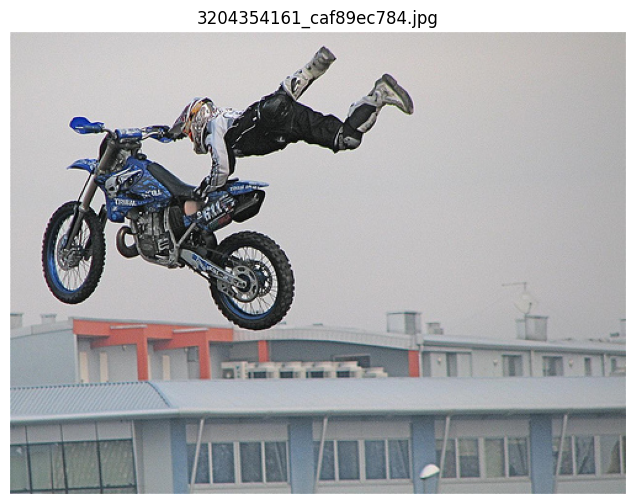

d:\FSB\AIN501-HocSau\Final\image-captioning\venv\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 4, 30, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Image: 3204354161_caf89ec784.jpg
Generated (No Dropout): a man on a bike is doing a trick on a dirt bike
Generated (Dropout=0.1): a man is doing a trick on a bicycle in the air
Generated (Dropout=0.3): a man is performing a trick on a bike

Ground truth:
- "a dirt biker performs a trick in midair ,"
- a driver gets high in the air with his motorbike .
- a motocross racer does a trick in midair .
- man performing stunts with his motorcycle .
- the man is hanging off the back of the motocross bike as it is jumping through the air .


In [26]:
from tensorflow.keras.models import load_model

img_name = test_imgs[45]

model_no_drop = load_caption_model(
    os.path.join("checkpoints/dropout_0", "best.keras")
)

model_drop_01 = load_caption_model(
    os.path.join("checkpoints/dropout_01", "best.keras")
)

model_drop_03 = load_caption_model(
    os.path.join("checkpoints/dropout_03", "best.keras")
)

# ===== Draw image =====
img_path = os.path.join(image_folder, img_name)

img = tf.keras.preprocessing.image.load_img(img_path)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title(img_name)
plt.show()

# ===== Generate captions =====
feature = get_feature(img_name)

caption_no_drop = generate_caption(model_no_drop, feature)
caption_drop_01 = generate_caption(model_drop_01, feature)
caption_drop_03 = generate_caption(model_drop_03, feature)

print("Image:", img_name)
print("Generated (No Dropout):", caption_no_drop)
print("Generated (Dropout=0.1):", caption_drop_01)
print("Generated (Dropout=0.3):", caption_drop_03)
print("\nGround truth:")
for c in captions_dict[img_name]:
    clean = c.replace("startseq", "").replace("endseq", "").strip()
    print("-", clean)

In [27]:
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu

def evaluate_bleu(model, captions_dict, image_names):
    scores = []

    # Quickly evaluate on a subset of test images to save time
    for img_name in image_names[:100]:
        feature = get_feature(img_name)

        pred = generate_caption(model, feature)

        refs = [
            c.replace("startseq", "").replace("endseq", "").split()
            for c in captions_dict[img_name]
        ]

        smooth = SmoothingFunction().method1
        score = sentence_bleu(refs, pred.split(), smoothing_function=smooth)
        scores.append(score)

    return np.mean(scores)

In [29]:
bleu_no_drop = evaluate_bleu(model_no_drop, captions_dict, test_imgs)
bleu_01 = evaluate_bleu(model_drop_01, captions_dict, test_imgs)
bleu_03 = evaluate_bleu(model_drop_03, captions_dict, test_imgs)

print("BLEU score (No Dropout):", bleu_no_drop) 
print("BLEU score (Dropout=0.1):", bleu_01)
print("BLEU score (Dropout=0.3):", bleu_03)

BLEU score (No Dropout): 0.14420826322818284
BLEU score (Dropout=0.1): 0.14118714097530138
BLEU score (Dropout=0.3): 0.15075756580302976


In [30]:
import matplotlib.pyplot as plt

def plot_loss(histories, labels):
    plt.figure()

    for history, label in zip(histories, labels):
        plt.plot(history.history['loss'], label=f'{label} - train')
        plt.plot(history.history['val_loss'], linestyle='--', label=f'{label} - val')

    plt.title('Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.show()

In [31]:
def plot_perplexity(histories, labels):
    plt.figure()

    for history, label in zip(histories, labels):
        plt.plot(history.history['perplexity'], label=f'{label} - train')
        plt.plot(history.history['val_perplexity'], linestyle='--', label=f'{label} - val')

    plt.title('Perplexity Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.legend()
    plt.grid()

    plt.show()

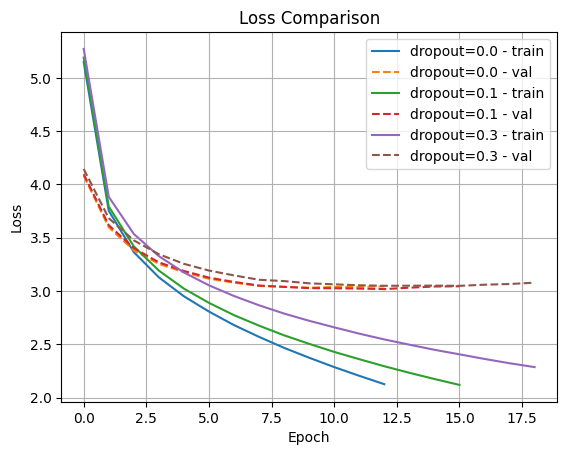

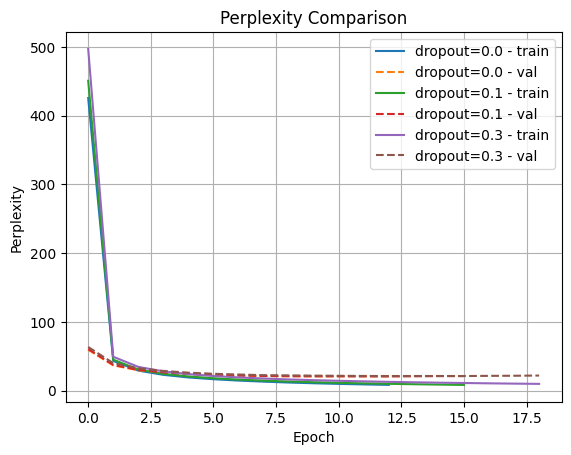

In [32]:
histories = [
    history_no_drop,
    history_drop_01,
    history_drop_03
]

labels = [
    "dropout=0.0",
    "dropout=0.1",
    "dropout=0.3"
]

plot_loss(histories, labels)
plot_perplexity(histories, labels)

In [33]:
def print_final_metrics(histories, labels):
    for history, label in zip(histories, labels):
        val_loss = history.history['val_loss'][-1]
        val_ppl = history.history['val_perplexity'][-1]

        print(f"{label}: val_loss={val_loss:.4f}, val_perplexity={val_ppl:.2f}")

In [34]:
print_final_metrics(histories, labels)

dropout=0.0: val_loss=3.0437, val_perplexity=21.19
dropout=0.1: val_loss=3.0445, val_perplexity=21.21
dropout=0.3: val_loss=3.0785, val_perplexity=22.00


In [35]:
import pickle

val_losses = [
    min(history_no_drop.history['val_loss']),
    min(history_drop_01.history['val_loss']),
    min(history_drop_03.history['val_loss'])
]

models = [
    model_no_drop,
    model_drop_01,
    model_drop_03
]

labels = [
    "no_drop",
    "drop_01",
    "drop_03"
]

best_idx = np.argmin(val_losses)

print("Best model:", labels[best_idx])

models[best_idx].save("best_model.keras")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

config = {
    "max_length": max_length,
    "dropout": [0.0, 0.1, 0.3][best_idx]
}

with open("config.pkl", "wb") as f:
    pickle.dump(config, f)

Best model: drop_01


In [37]:
# ==================================
# RESUME TRAINING (RUN ONLY IF NEEDED)
# ==================================

# resumed_model = tf.keras.models.load_model(
#     "checkpoints/dropout_01/latest.keras",
#     custom_objects={
#         "masked_loss": masked_loss,
#         "perplexity": perplexity,
#         "PositionalEmbedding": PositionalEmbedding
#     }
# )

# train_dataset, test_dataset = get_datasets()

# history_resume = resumed_model.fit(
#     train_dataset,
#     validation_data=test_dataset,
#     initial_epoch=10,   # số epoch đã train xong
#     epochs=20,
#     steps_per_epoch=steps_per_epoch,
#     validation_steps=val_steps,
#     callbacks=get_callbacks("dropout_01")
# )

In [38]:
# Evaluate BLEU on the full test set
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu
import numpy as np

def evaluate_bleu_full(model, captions_dict, image_names):
    scores = []
    smooth = SmoothingFunction().method1

    total = len(image_names)

    for i, img_name in enumerate(image_names):
        if i % 100 == 0:
            print(f"Evaluating {i}/{total}")

        feature = get_feature(img_name)

        pred = generate_caption(model, feature)

        refs = [
            c.replace("startseq", "").replace("endseq", "").split()
            for c in captions_dict[img_name]
        ]

        score = sentence_bleu(
            refs,
            pred.split(),
            smoothing_function=smooth
        )

        scores.append(score)

    return np.mean(scores)

In [39]:
full_bleu_no_drop = evaluate_bleu_full(model_no_drop, captions_dict, test_imgs)
full_bleu_01 = evaluate_bleu_full(model_drop_01, captions_dict, test_imgs)
full_bleu_03 = evaluate_bleu_full(model_drop_03, captions_dict, test_imgs)

print("Full BLEU score (No Dropout):", full_bleu_no_drop) 
print("Full BLEU score (Dropout=0.1):", full_bleu_01)
print("Full BLEU score (Dropout=0.3):", full_bleu_03)

Evaluating 0/1619
Evaluating 100/1619
Evaluating 200/1619
Evaluating 300/1619
Evaluating 400/1619
Evaluating 500/1619
Evaluating 600/1619
Evaluating 700/1619
Evaluating 800/1619
Evaluating 900/1619
Evaluating 1000/1619
Evaluating 1100/1619
Evaluating 1200/1619
Evaluating 1300/1619
Evaluating 1400/1619
Evaluating 1500/1619
Evaluating 1600/1619
Evaluating 0/1619
Evaluating 100/1619
Evaluating 200/1619
Evaluating 300/1619
Evaluating 400/1619
Evaluating 500/1619
Evaluating 600/1619
Evaluating 700/1619
Evaluating 800/1619
Evaluating 900/1619
Evaluating 1000/1619
Evaluating 1100/1619
Evaluating 1200/1619
Evaluating 1300/1619
Evaluating 1400/1619
Evaluating 1500/1619
Evaluating 1600/1619
Evaluating 0/1619
Evaluating 100/1619
Evaluating 200/1619
Evaluating 300/1619
Evaluating 400/1619
Evaluating 500/1619
Evaluating 600/1619
Evaluating 700/1619
Evaluating 800/1619
Evaluating 900/1619
Evaluating 1000/1619
Evaluating 1100/1619
Evaluating 1200/1619
Evaluating 1300/1619
Evaluating 1400/1619
Evaluat